In [1]:
import sys
sys.path.append(".")
from data_prep import load_and_clean, add_gam_features

df_full, df_model_ready = load_and_clean("../../clean_data/Model_Ready.csv")
gam_df = add_gam_features(df_model_ready)

print(gam_df.columns.tolist())
gam_df.head()

['month', 'total_people_served', 'year', 'month_num', 'total_people_served_lag1', 'total_people_served_lag2', 'total_people_served_lag3', 'total_people_served_lag6', 'total_people_served_lag12', 'total_people_served_rollingavg3', 'total_people_served_rollingavg6', 'total_people_served_rollingavg12', 'ow_cases_official_lag1', 'ow_beneficiaries_lag1', 'odsp_cases_official_lag1', 'odsp_beneficiaries_lag1', 'total_homeless_lag1', 'total_chronic_homeless_lag1', 'cpi_all_items_lag1', 'cpi_food_lag1', 'cpi_shelter_lag1', 'unemployment_rate_lag1', 'time_index', 'log_total_people_served']


,month,total_people_served,year,month_num,total_people_served_lag1,total_people_served_lag2,total_people_served_lag3,total_people_served_lag6,total_people_served_lag12,total_people_served_rollingavg3,...,odsp_cases_official_lag1,odsp_beneficiaries_lag1,total_homeless_lag1,total_chronic_homeless_lag1,cpi_all_items_lag1,cpi_food_lag1,cpi_shelter_lag1,unemployment_rate_lag1,time_index,log_total_people_served
0,2019-02-01,15168,2019,2,17755.0,14797.0,20868.0,17136.0,15284.0,17806.666667,...,12724.0,17491.0,754.0,293.0,135.2,151.6,145.0,5.6,0,9.626943
1,2019-03-01,17519,2019,3,15168.0,17755.0,14797.0,14976.0,16676.0,15906.666667,...,12728.0,17528.0,725.0,298.0,136.0,151.9,145.5,5.6,1,9.771041
2,2019-04-01,16438,2019,4,17519.0,15168.0,17755.0,16940.0,15171.0,16814.000000,...,12783.0,17615.0,738.0,302.0,137.0,151.9,145.8,5.9,2,9.707351
3,2019-05-01,19111,2019,5,16438.0,17519.0,15168.0,20868.0,16933.0,16375.000000,...,12742.0,17578.0,764.0,327.0,137.4,151.8,146.5,5.9,3,9.858019
4,2019-06-01,16486,2019,6,19111.0,16438.0,17519.0,14797.0,15122.0,17689.333333,...,12800.0,17646.0,758.0,363.0,138.1,152.7,146.6,5.2,4,9.710267


Candidate driver columns:
 ['total_people_served_lag1', 'ow_cases_official_lag1', 'ow_beneficiaries_lag1', 'odsp_cases_official_lag1', 'odsp_beneficiaries_lag1', 'total_homeless_lag1', 'total_chronic_homeless_lag1', 'cpi_all_items_lag1', 'cpi_food_lag1', 'cpi_shelter_lag1', 'unemployment_rate_lag1']


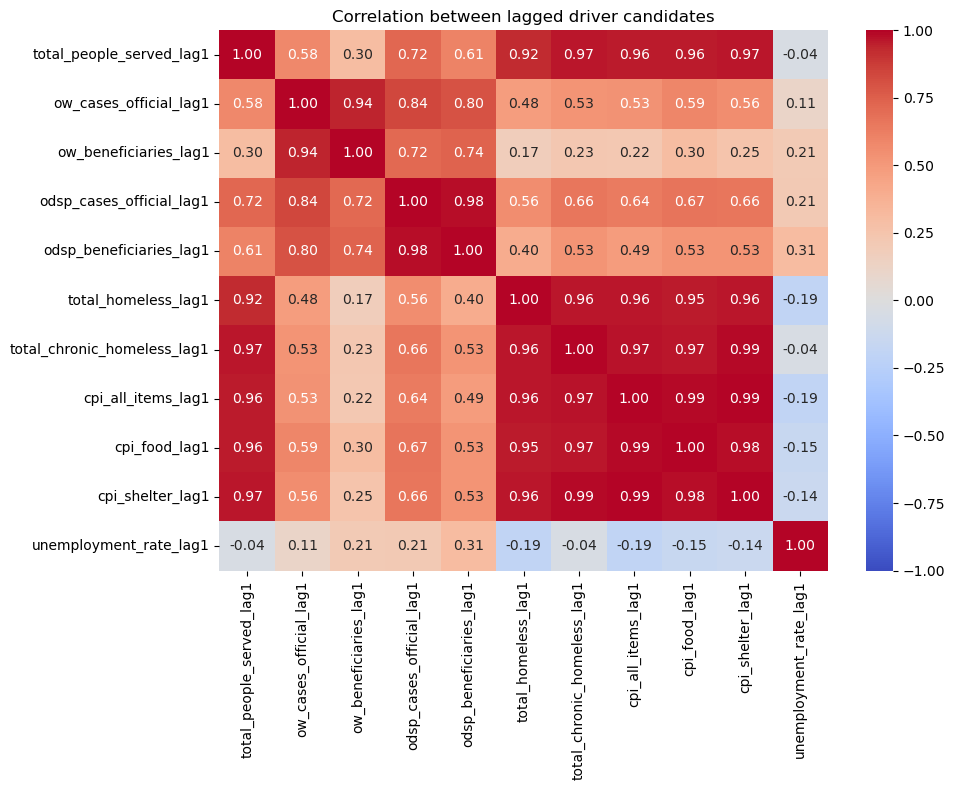

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

candidate_drivers = [c for c in gam_df.columns if c.endswith("_lag1")]
print("Candidate driver columns:\n", candidate_drivers)

corr_matrix = gam_df[candidate_drivers].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between lagged driver candidates")
plt.tight_layout()
plt.show()

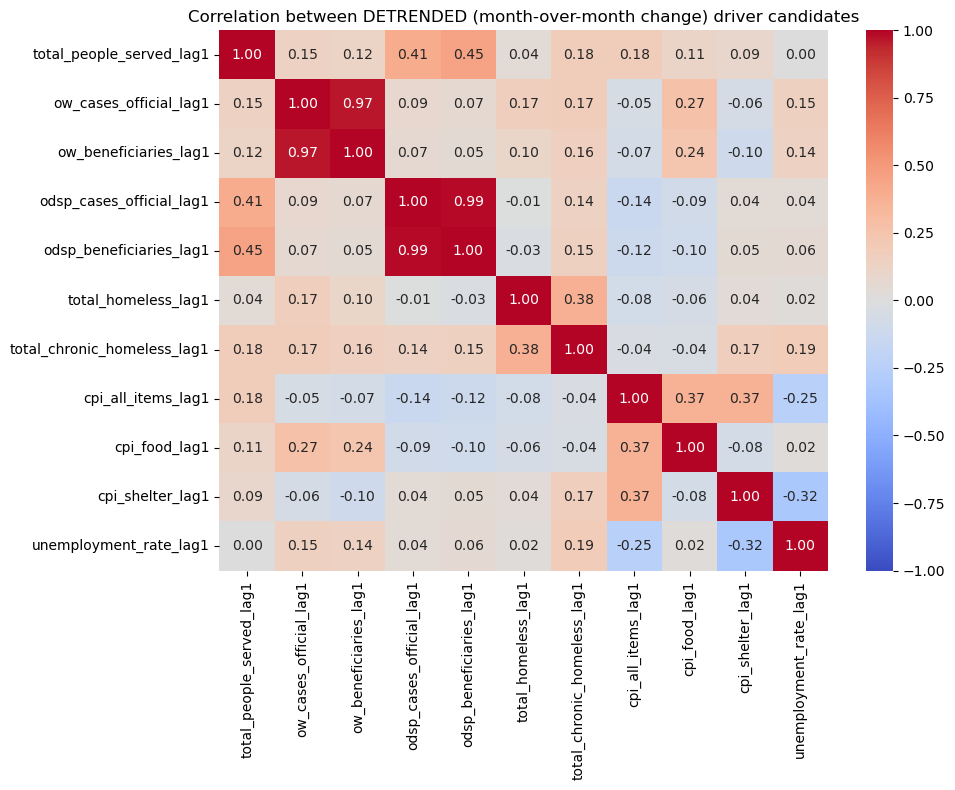

In [3]:
# Detrend each series (difference it), then re-check correlation.
# If correlations drop sharply after detrending, the original correlation
# was mostly driven by shared trend, not a real relationship.

detrended = gam_df[candidate_drivers].diff().dropna()

detrended_corr = detrended.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(detrended_corr, annot=True, fmt=".2f", cmap="coolwarm", center=0, vmin=-1, vmax=1)
plt.title("Correlation between DETRENDED (month-over-month change) driver candidates")
plt.tight_layout()
plt.show()

In [4]:
selected_drivers = [
    "unemployment_rate_lag1",
    "odsp_cases_official_lag1",
    "cpi_food_lag1",
]

print(gam_df[selected_drivers + ["total_people_served", "log_total_people_served"]].isna().sum())

unemployment_rate_lag1      0
odsp_cases_official_lag1    0
cpi_food_lag1               0
total_people_served         0
log_total_people_served     0
dtype: int64


In [5]:
test_start = "2025-07-01"

train = gam_df[gam_df["month"] < test_start].reset_index(drop=True)
test = gam_df[gam_df["month"] >= test_start].reset_index(drop=True)

print(f"Train: {train['month'].min()} to {train['month'].max()}, {len(train)} rows")
print(f"Test: {test['month'].min()} to {test['month'].max()}, {len(test)} rows")

Train: 2019-02-01 00:00:00 to 2025-06-01 00:00:00, 77 rows
Test: 2025-07-01 00:00:00 to 2026-06-01 00:00:00, 12 rows


In [7]:
from pygam import LinearGAM, s

X_train_simple = train[["time_index", "month_num"]].values
y_train = train["log_total_people_served"].values

gam_simple = LinearGAM(
    s(0, n_splines=8) +
    s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12)
).gridsearch(X_train_simple, y_train)

print(gam_simple.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      5.0731
Link Function:                     IdentityLink Log Likelihood:                                 -4643.2638
Number of Samples:                           77 AIC:                                             9298.6737
                                                AICc:                                            9299.9023
                                                GCV:                                                0.0082
                                                Scale:                                              0.0073
                                                Pseudo R-Squared:                                   0.9541
Feature Function                  Lam

/var/folders/c0/_bdz8pfs6jzgzj64v2bfpgxc0000gn/T/ipykernel_4226/1603851096.py:11: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_simple.summary())


In [8]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error

def wape(actual, predicted):
    return np.sum(np.abs(actual - predicted)) / np.sum(np.abs(actual)) * 100

X_test_simple = test[["time_index", "month_num"]].values
pred_log_baseline = gam_simple.predict(X_test_simple)
pred_baseline = np.exp(pred_log_baseline)

actual = test["total_people_served"].values

print("BASELINE (trend + seasonality only)")
print("MAE:", mean_absolute_error(actual, pred_baseline))
print("RMSE:", np.sqrt(mean_squared_error(actual, pred_baseline)))
print("WAPE:", wape(actual, pred_baseline), "%")

BASELINE (trend + seasonality only)
MAE: 10331.813146245957
RMSE: 11060.713138843985
WAPE: 18.48498585913434 %


In [24]:
feature_cols = ["time_index", "month_num"] + selected_drivers

X_train_full = train[feature_cols].values
X_test_full = test[feature_cols].values

gam_full = LinearGAM(
    s(0, n_splines=8) +                                   # trend
    s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12) +    # seasonality
    s(2, n_splines=8) +                                    # unemployment_rate_lag1
    s(3, n_splines=8) +                                     # odsp_cases_official_lag1
    s(4, n_splines=8)                                       # cpi_food_lag1
).gridsearch(X_train_full, y_train)

print(gam_full.summary())

gam_full_v2 = LinearGAM(
    s(0, n_splines=4, lam=50) +                              # much coarser trend, heavier smoothing penalty
    s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12) +
    s(2, n_splines=8) +
    s(3, n_splines=8) +
    s(4, n_splines=8)
).fit(X_train_full, y_train)   # fit directly with a fixed lam rather than gridsearch, to force the smoother trend

pred_log_v2 = gam_full_v2.predict(X_test_full)
pred_v2 = np.exp(pred_log_v2)

print("MAE:", mean_absolute_error(actual, pred_v2))
print("RMSE:", np.sqrt(mean_squared_error(actual, pred_v2)))
print("WAPE:", wape(actual, pred_v2), "%")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 54% (6 of 11) |#############            | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 81% (9 of 11) |####################     | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      8.0729
Link Function:                     IdentityLink Log Likelihood:                                 -4754.0464
Number of Samples:                           77 AIC:                                             9526.2386
                                                AICc:                                            9528.9697
                                                GCV:                                                0.0084
                                                Scale:                                              0.0068
                                                Pseudo R-Squared:                                   0.9588
Feature Function                  Lam

/var/folders/c0/_bdz8pfs6jzgzj64v2bfpgxc0000gn/T/ipykernel_4226/1347459800.py:14: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam_full.summary())


In [19]:
pred_log_full = gam_full.predict(X_test_full)
pred_full = np.exp(pred_log_full)

print("FULL MODEL (trend + seasonality + drivers)")
print("MAE:", mean_absolute_error(actual, pred_full))
print("RMSE:", np.sqrt(mean_squared_error(actual, pred_full)))
print("WAPE:", wape(actual, pred_full), "%")

print("\n--- Comparison ---")
print(f"Baseline WAPE: {wape(actual, pred_baseline):.2f}%")
print(f"Full model WAPE: {wape(actual, pred_full):.2f}%")
improvement = wape(actual, pred_baseline) - wape(actual, pred_full)
print(f"Improvement: {improvement:.2f} percentage points")

FULL MODEL (trend + seasonality + drivers)
MAE: 7619.06250985086
RMSE: 8179.495885121214
WAPE: 13.63151469745918 %

--- Comparison ---
Baseline WAPE: 18.48%
Full model WAPE: 13.63%
Improvement: 4.85 percentage points


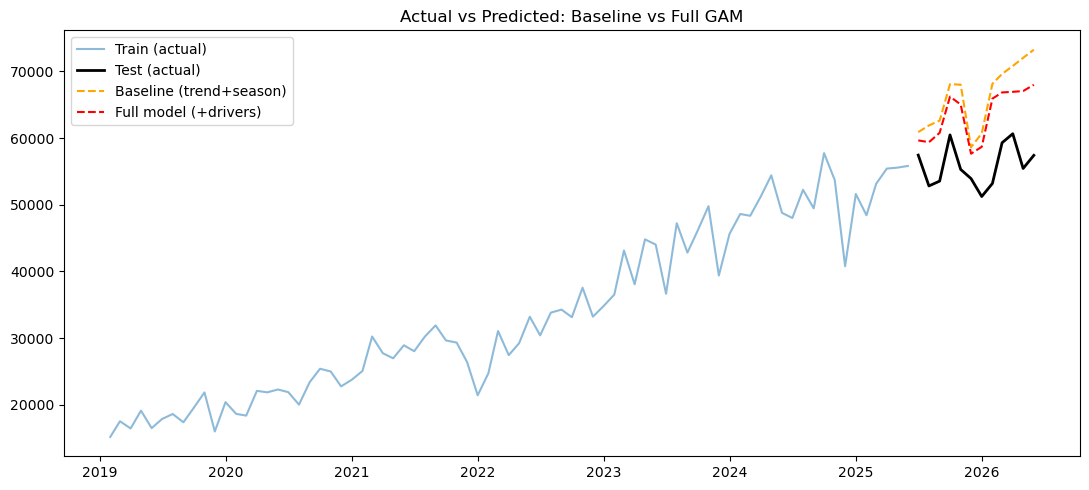

In [20]:
import matplotlib.pyplot as plt

plt.figure(figsize=(11, 5))
plt.plot(train["month"], train["total_people_served"], label="Train (actual)", alpha=0.5)
plt.plot(test["month"], actual, label="Test (actual)", color="black", linewidth=2)
plt.plot(test["month"], pred_baseline, label="Baseline (trend+season)", linestyle="--", color="orange")
plt.plot(test["month"], pred_full, label="Full model (+drivers)", linestyle="--", color="red")
plt.legend()
plt.title("Actual vs Predicted: Baseline vs Full GAM")
plt.tight_layout()
plt.show()

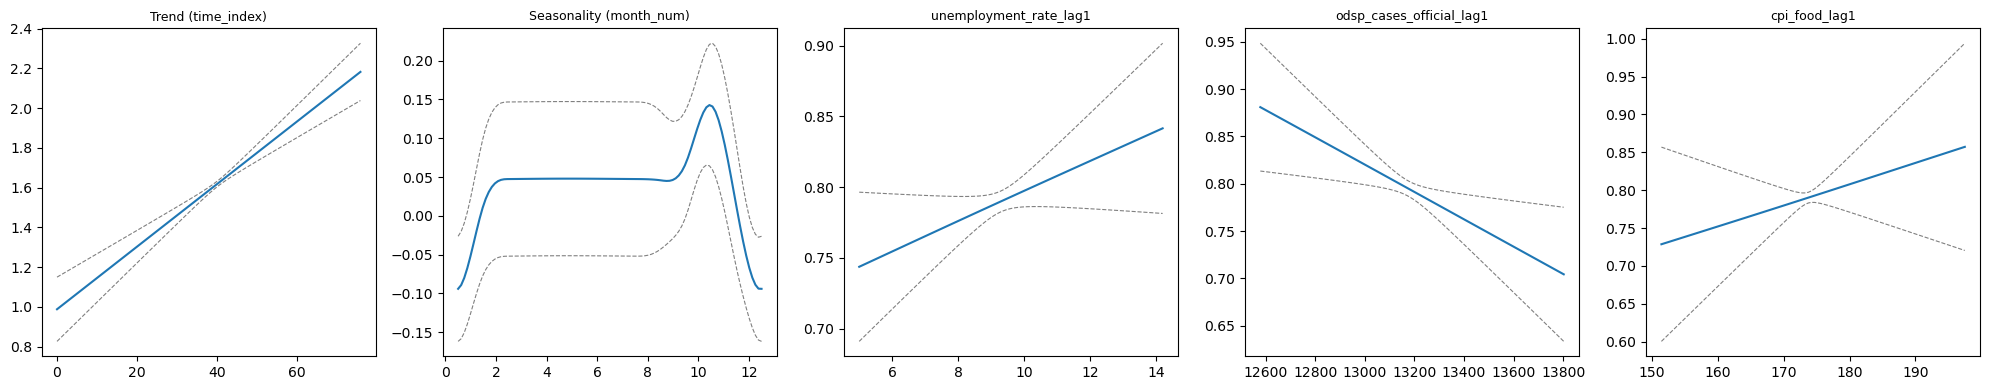

In [21]:
term_names = ["Trend (time_index)", "Seasonality (month_num)"] + selected_drivers

fig, axes = plt.subplots(1, len(term_names), figsize=(4*len(term_names), 4))

for i, ax in enumerate(axes):
    XX = gam_full.generate_X_grid(term=i)
    pdep, confi = gam_full.partial_dependence(term=i, X=XX, width=0.95)
    ax.plot(XX[:, i], pdep)
    ax.plot(XX[:, i], confi[:, 0], c="gray", ls="--", linewidth=0.8)
    ax.plot(XX[:, i], confi[:, 1], c="gray", ls="--", linewidth=0.8)
    ax.set_title(term_names[i], fontsize=9)

plt.tight_layout()
plt.show()

In [23]:
range2_start = "2022-01-01"

train_r2 = gam_df[(gam_df["month"] >= range2_start) & (gam_df["month"] < test_start)].reset_index(drop=True)

X_train_r2 = train_r2[feature_cols].values
y_train_r2 = train_r2["log_total_people_served"].values

gam_range2 = LinearGAM(
    s(0, n_splines=8) +
    s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12) +
    s(2, n_splines=8) +
    s(3, n_splines=8) +
    s(4, n_splines=8)
).gridsearch(X_train_r2, y_train_r2)

pred_log_r2 = gam_range2.predict(X_test_full)
pred_r2 = np.exp(pred_log_r2)

print("RANGE 2 MODEL (trained 2022-2025 only)")
print("MAE:", mean_absolute_error(actual, pred_r2))
print("RMSE:", np.sqrt(mean_squared_error(actual, pred_r2)))
print("WAPE:", wape(actual, pred_r2), "%")

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
 18% (2 of 11) |####                     | Elapsed Time: 0:00:00 ETA:   0:00:00
 36% (4 of 11) |#########                | Elapsed Time: 0:00:00 ETA:   0:00:00
 63% (7 of 11) |###############          | Elapsed Time: 0:00:00 ETA:   0:00:00
 72% (8 of 11) |##################       | Elapsed Time: 0:00:00 ETA:   0:00:00
 90% (10 of 11) |#####################   | Elapsed Time: 0:00:00 ETA:   0:00:00
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


RANGE 2 MODEL (trained 2022-2025 only)
MAE: 11922.140694143212
RMSE: 13222.776822939551
WAPE: 21.33029304947527 %


In [27]:
import pandas as pd
results_grid = []

for n_spl in [4, 5, 6, 7]:
    for lam_val in [20, 50, 100, 200]:
        gam_test = LinearGAM(
            s(0, n_splines=n_spl, lam=lam_val) +
            s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12) +
            s(2, n_splines=8) + s(3, n_splines=8) + s(4, n_splines=8)
        ).fit(X_train_full, y_train)

        pred_test = np.exp(gam_test.predict(X_test_full))
        w = wape(actual, pred_test)
        results_grid.append({"n_splines": n_spl, "lam": lam_val, "wape": w})

results_df = pd.DataFrame(results_grid).sort_values("wape")
print(results_df.head(10))

    n_splines  lam      wape
12          7   20  8.478161
13          7   50  8.521319
8           6   20  8.524048
14          7  100  8.536083
9           6   50  8.540140
15          7  200  8.543538
4           5   20  8.543799
10          6  100  8.545575
5           5   50  8.548138
11          6  200  8.548305


In [28]:
gam_final = LinearGAM(
    s(0, n_splines=7, lam=20) +
    s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12) +
    s(2, n_splines=8) + s(3, n_splines=8) + s(4, n_splines=8)
).fit(X_train_full, y_train)

pred_log_final = gam_final.predict(X_test_full)
pred_final = np.exp(pred_log_final)

print("FINAL MODEL")
print("MAE:", mean_absolute_error(actual, pred_final))
print("RMSE:", np.sqrt(mean_squared_error(actual, pred_final)))
print("WAPE:", wape(actual, pred_final), "%")

FINAL MODEL
MAE: 4738.698346635137
RMSE: 5599.380208048374
WAPE: 8.47816067599724 %


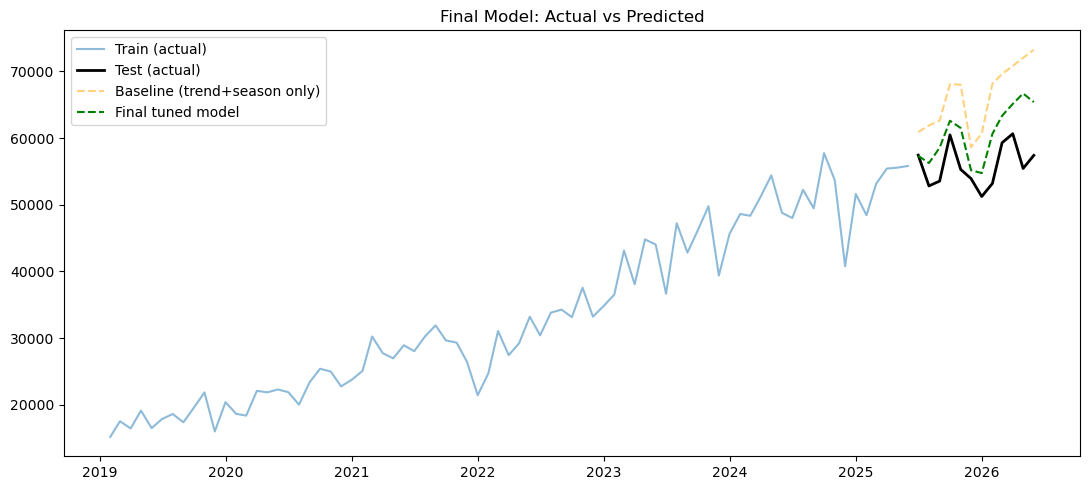

In [29]:
plt.figure(figsize=(11, 5))
plt.plot(train["month"], train["total_people_served"], label="Train (actual)", alpha=0.5)
plt.plot(test["month"], actual, label="Test (actual)", color="black", linewidth=2)
plt.plot(test["month"], pred_baseline, label="Baseline (trend+season only)", linestyle="--", color="orange", alpha=0.5)
plt.plot(test["month"], pred_final, label="Final tuned model", linestyle="--", color="green")
plt.legend()
plt.title("Final Model: Actual vs Predicted")
plt.tight_layout()
plt.show()

Mean residual (actual - predicted): -4721.302778162795
Median residual: -4261.996480362453
% of months where predicted > actual: 91.66666666666666 %


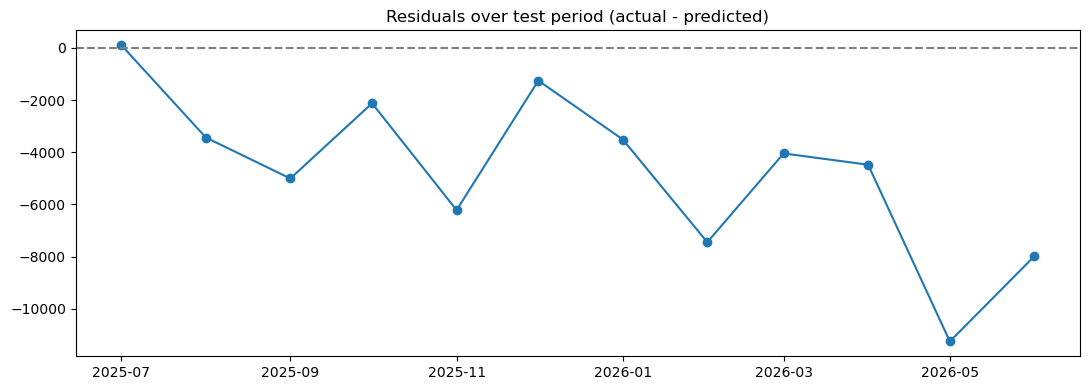

In [30]:
residuals = actual - pred_final

print("Mean residual (actual - predicted):", residuals.mean())
print("Median residual:", np.median(residuals))
print("% of months where predicted > actual:", (pred_final > actual).mean() * 100, "%")

plt.figure(figsize=(11, 4))
plt.plot(test["month"], residuals, marker="o")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Residuals over test period (actual - predicted)")
plt.tight_layout()
plt.show()

In [31]:
# Refit the SAME model structure but on raw total_people_served, not log-transformed
y_train_raw = train["total_people_served"].values

gam_final_raw = LinearGAM(
    s(0, n_splines=7, lam=20) +
    s(1, basis="cp", edge_knots=[0.5, 12.5], n_splines=12) +
    s(2, n_splines=8) + s(3, n_splines=8) + s(4, n_splines=8)
).fit(X_train_full, y_train_raw)

pred_raw = gam_final_raw.predict(X_test_full)  # no exp() needed, already on original scale

print("RAW-SCALE MODEL (no log transform)")
print("MAE:", mean_absolute_error(actual, pred_raw))
print("RMSE:", np.sqrt(mean_squared_error(actual, pred_raw)))
print("WAPE:", wape(actual, pred_raw), "%")
print("Mean residual:", (actual - pred_raw).mean())

RAW-SCALE MODEL (no log transform)
MAE: 4206.704004509425
RMSE: 4879.670372362129
WAPE: 7.5263521451871 %
Mean residual: -3974.260034594399


Mean residual (raw-scale model): -3974.260034594399
% of months where predicted > actual: 83.33333333333334 %


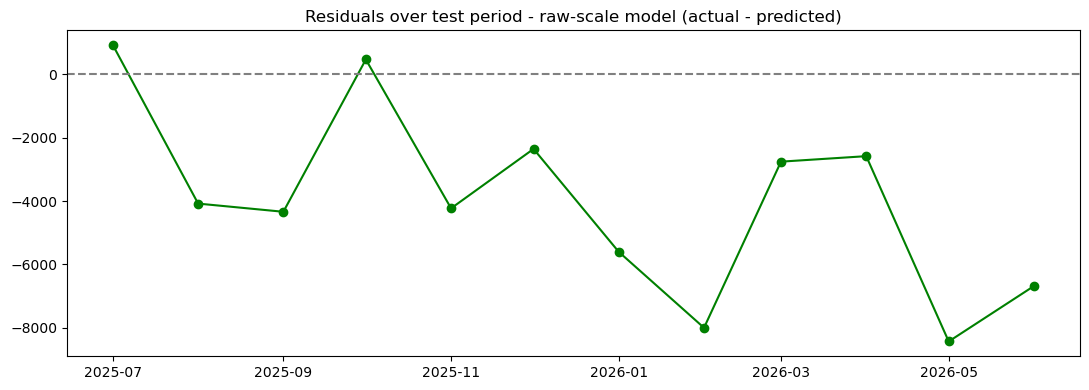

In [33]:
residuals_raw = actual - pred_raw

print("Mean residual (raw-scale model):", residuals_raw.mean())
print("% of months where predicted > actual:", (pred_raw > actual).mean() * 100, "%")

plt.figure(figsize=(11, 4))
plt.plot(test["month"], residuals_raw, marker="o", color="green")
plt.axhline(0, color="gray", linestyle="--")
plt.title("Residuals over test period - raw-scale model (actual - predicted)")
plt.tight_layout()
plt.show()